# Business Analytics and Visualisation
Assessment 1 — Part 2 (Session 4)

Student ID: s8200703
Dataset: AusiFood_Foodsupplier.xlsx

This notebook is created separately for Part 2. It follows a reproducible workflow of importing, inspecting, cleaning, transforming, analysing, visualising, and interpreting the data.

Only pandas, seaborn, and matplotlib are imported.

## 1. Import libraries

pandas is used for data manipulation, while seaborn and matplotlib are used for visualisation. Graph styles, decimal points etc styles are set.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Import the dataset

The workbook is loaded again specifically for Part 2. The DataFrame is named using the student ID.

In [2]:
s8200703 = pd.read_excel("AusiFood_Foodsupplier.xlsx")

print("Dataset imported successfully.")
print(f"Rows: {s8200703.shape[0]:,}")
print(f"Columns: {s8200703.shape[1]}")

Dataset imported successfully.
Rows: 900
Columns: 21


## 3. Preview the dataset

The first five records are displayed with serial numbers beginning at 1 for presentation.

In [3]:
preview = s8200703.head().copy()
preview.index = range(1, len(preview) + 1)
preview.index.name = "Serial Number"
display(preview)

,Item_id,Item,Category,Store,Supplier,Supplier location,City,Payment method,quantity,Item sold,purchase price,total cost,sold price,Discounts,total sales,Date,Month Number,Month Name,Year,product feedback,other feedback
Serial Number,,,,,,,,,,,,,,,,,,,,,
1,1122,Bulk Almonds 15kg,Bulk & Pantry,Grocery,Mediterranean Wholesalers,VIC,Kensington and Flemington,credit_card,58,57,165.00,"9,570.00",188.10,0.00,"10,721.70",2017-01-02,1,January,2017,neutral,order was as expected
2,1123,Tomatoes,Vegetables,Market,Kahvecioglu Grand Foods,Tasmania,Northcote,cash,556,556,2.00,"1,112.00",2.86,79.51,"1,510.65",2017-01-02,1,January,2017,strongly disagree,no one responded to my email
3,1124,Tomatoes,Vegetables,Market,Kahvecioglu Grand Foods,VIC,Northcote,credit_card,1906,1864,2.00,"3,812.00",2.86,186.59,"5,144.45",2017-01-03,1,January,2017,agree,I like your product
4,1125,Cheese,Dairy & Eggs,Home Delivery,First Ray,Australian Capital Territory,Southbank,credit_card,876,834,5.00,"4,380.00",6.37,265.63,"5,046.95",2017-01-06,1,January,2017,agree,I like your product
5,1126,Sour cream,Dairy & Eggs,Home Delivery,Basfoods Direct - Somerton Store,Tasmania,Kensington and Flemington,credit_card,217,202,6.00,"1,302.00",6.60,66.66,"1,266.54",2017-01-10,1,January,2017,neutral,no comment


## 4. Inspect and clean the data

The dataset structure, missing values, and duplicate rows are checked. A working copy is then created to preserve the original imported DataFrame.

In [4]:
s8200703.info()

quality_check = pd.DataFrame({
    "Check": ["Rows", "Columns", "Missing values", "Duplicate rows"],
    "Result": [
        len(s8200703),
        s8200703.shape[1],
        int(s8200703.isna().sum().sum()),
        int(s8200703.duplicated().sum())
    ]
})
quality_check.insert(0, "Serial Number", range(1, len(quality_check)+1))
display(quality_check.style.hide(axis="index"))

s8200703_part2 = s8200703.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Item_id            900 non-null    int64         
 1   Item               900 non-null    object        
 2   Category           900 non-null    object        
 3   Store              900 non-null    object        
 4   Supplier           900 non-null    object        
 5   Supplier location  900 non-null    object        
 6   City               900 non-null    object        
 7   Payment method     900 non-null    object        
 8   quantity           900 non-null    int64         
 9   Item sold          900 non-null    int64         
 10  purchase price     900 non-null    float64       
 11  total cost         900 non-null    float64       
 12  sold price         900 non-null    float64       
 13  Discounts          900 non-null    float64       
 14  total sale

Serial Number,Check,Result
1,Rows,900
2,Columns,21
3,Missing values,0
4,Duplicate rows,0


## 5. Standardise text and state names

Text fields are stripped of extra spaces, product feedback is converted to lowercase, and supplier locations are converted to standard Australian abbreviations.

In [5]:
for column in ["Item", "Supplier location", "City", "product feedback"]:
    s8200703_part2[column] = s8200703_part2[column].astype(str).str.strip()

s8200703_part2["product feedback"] = s8200703_part2["product feedback"].str.lower()

state_abbreviations = {
    "Victoria": "VIC", "VIC": "VIC",
    "New South Wales": "NSW", "NSW": "NSW",
    "Queensland": "QLD", "QLD": "QLD",
    "Western Australia": "WA", "WA": "WA",
    "South Australia": "SA", "SA": "SA",
    "Tasmania": "TAS", "TAS": "TAS",
    "Northern Territory": "NT", "NT": "NT",
    "Australian Capital Territory": "ACT", "ACT": "ACT"
}

s8200703_part2["Supplier location"] = (
    s8200703_part2["Supplier location"].replace(state_abbreviations)
)

print(sorted(s8200703_part2["Supplier location"].unique()))

['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']


## Question 1 — Product Feedback
6. Identify unique feedback values

The unique values in product feedback need to be identified before classifying positive feedback.

In [6]:
feedback_values = (
    s8200703_part2["product feedback"]
    .value_counts()
    .rename_axis("Product Feedback")
    .reset_index(name="Count")
)

feedback_values["Percentage"] = (
    feedback_values["Count"] / feedback_values["Count"].sum() * 100
).round(1)

feedback_values.insert(0, "Serial Number", range(1, len(feedback_values)+1))

display(
    feedback_values.style
    .format({"Count": "{:,.0f}", "Percentage": "{:.1f}%"})
    .hide(axis="index")
)

Serial Number,Product Feedback,Count,Percentage
1,agree,264,29.3%
2,neutral,208,23.1%
3,strongly agree,176,19.6%
4,disagree,161,17.9%
5,strongly disagree,91,10.1%


## 7. Define positive feedback and create a dictionary

For this analysis, positive feedback = agree or strongly agree. These categories explicitly represent favourable responses.

The dictionary converts feedback into a binary variable: 1 = Positive, 0 = Not positive.

In [7]:
positive_feedback_dictionary = {
    "strongly agree": 1,
    "agree": 1,
    "neutral": 0,
    "disagree": 0,
    "strongly disagree": 0
}

positive_feedback_dictionary

{'strongly agree': 1,
 'agree': 1,
 'neutral': 0,
 'disagree': 0,
 'strongly disagree': 0}

## 8. Create and count positive feedback

The dictionary is mapped to a new Positive Feedback column. The total count and overall percentage of positive responses are then calculated.

In [8]:
s8200703_part2["Positive Feedback"] = (
    s8200703_part2["product feedback"].map(positive_feedback_dictionary)
)

positive_feedback_count = int(s8200703_part2["Positive Feedback"].sum())
total_feedback_count = int(s8200703_part2["product feedback"].count())
positive_feedback_percentage = positive_feedback_count / total_feedback_count * 100

feedback_summary = pd.DataFrame({
    "Measure": [
        "Total feedback responses",
        "Positive responses",
        "Positive feedback percentage"
    ],
    "Result": [
        f"{total_feedback_count:,}",
        f"{positive_feedback_count:,}",
        f"{positive_feedback_percentage:.1f}%"
    ]
})
feedback_summary.insert(0, "Serial Number", range(1, len(feedback_summary)+1))
display(feedback_summary.style.hide(axis="index"))

Serial Number,Measure,Result
1,Total feedback responses,900
2,Positive responses,440
3,Positive feedback percentage,48.9%


## 9. Group positive feedback by state

For each state or territory, total responses, positive responses, and the positive-response percentage are calculated. Ranking by positive count identifies which state has the most positive feedback, while the percentage controls for differences in response volume.

In [9]:
feedback_by_state = (
    s8200703_part2
    .groupby("Supplier location", as_index=False)
    .agg(
        Total_Responses=("product feedback", "count"),
        Positive_Responses=("Positive Feedback", "sum")
    )
)

feedback_by_state["Positive_Percentage"] = (
    feedback_by_state["Positive_Responses"]
    / feedback_by_state["Total_Responses"] * 100
).round(1)

feedback_by_state = (
    feedback_by_state
    .sort_values("Positive_Responses", ascending=False)
    .reset_index(drop=True)
)

feedback_by_state.insert(0, "Serial Number", range(1, len(feedback_by_state)+1))

display(
    feedback_by_state.style
    .format({
        "Total_Responses": "{:,.0f}",
        "Positive_Responses": "{:,.0f}",
        "Positive_Percentage": "{:.1f}%"
    })
    .hide(axis="index")
)

Serial Number,Supplier location,Total_Responses,Positive_Responses,Positive_Percentage
1,VIC,314,185,58.9%
2,NSW,160,76,47.5%
3,QLD,125,47,37.6%
4,WA,90,44,48.9%
5,SA,75,34,45.3%
6,ACT,52,23,44.2%
7,TAS,51,23,45.1%
8,NT,33,8,24.2%


## 10. Identify the leading state

The first row of the ranked table provides the location with the highest positive-feedback count.

In [10]:
top_state = feedback_by_state.iloc[0]

print(f"State/Territory: {top_state['Supplier location']}")
print(f"Positive responses: {top_state['Positive_Responses']:,.0f}")
print(f"Positive percentage: {top_state['Positive_Percentage']:.1f}%")

State/Territory: VIC
Positive responses: 185
Positive percentage: 58.9%


## 11. Visualise positive feedback by state

A multicoloured horizontal bar chart compares positive-response counts across locations.

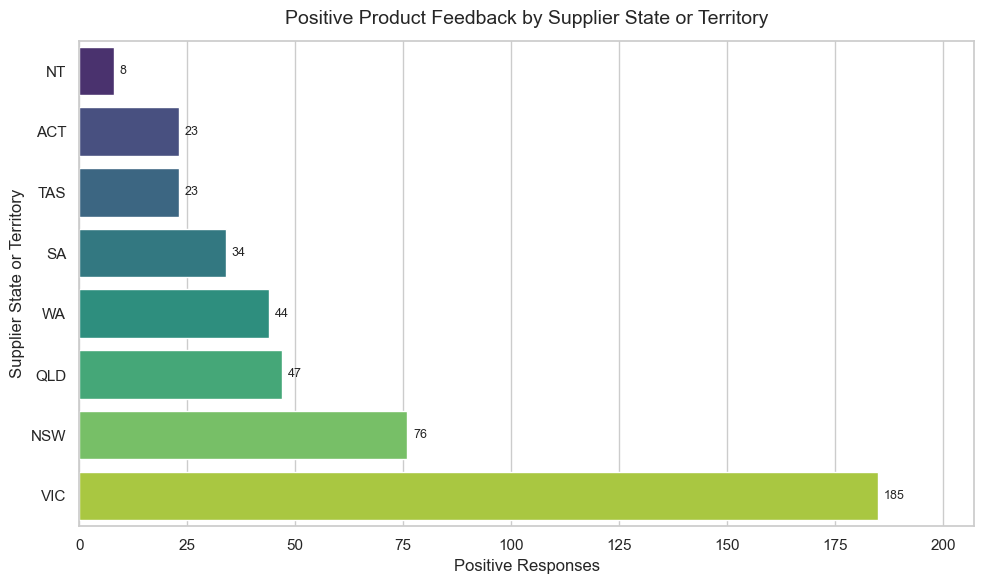

In [11]:
feedback_plot = feedback_by_state.sort_values("Positive_Responses", ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=feedback_plot,
    x="Positive_Responses",
    y="Supplier location",
    hue="Supplier location",
    palette="viridis",
    legend=False
)

ax.set_title("Positive Product Feedback by Supplier State or Territory", fontsize=14, pad=12)
ax.set_xlabel("Positive Responses")
ax.set_ylabel("Supplier State or Territory")

for bar in ax.patches:
    width = bar.get_width()
    if pd.notna(width):
        ax.annotate(
            f"{width:,.0f}",
            (width, bar.get_y() + bar.get_height()/2),
            xytext=(4, 0),
            textcoords="offset points",
            va="center",
            fontsize=9
        )

ax.margins(x=0.12)
plt.tight_layout()
plt.show()

## 12. Visualise positive-feedback percentage by state

Because states have different sample sizes, a second multicoloured chart compares the percentage of responses that were positive.

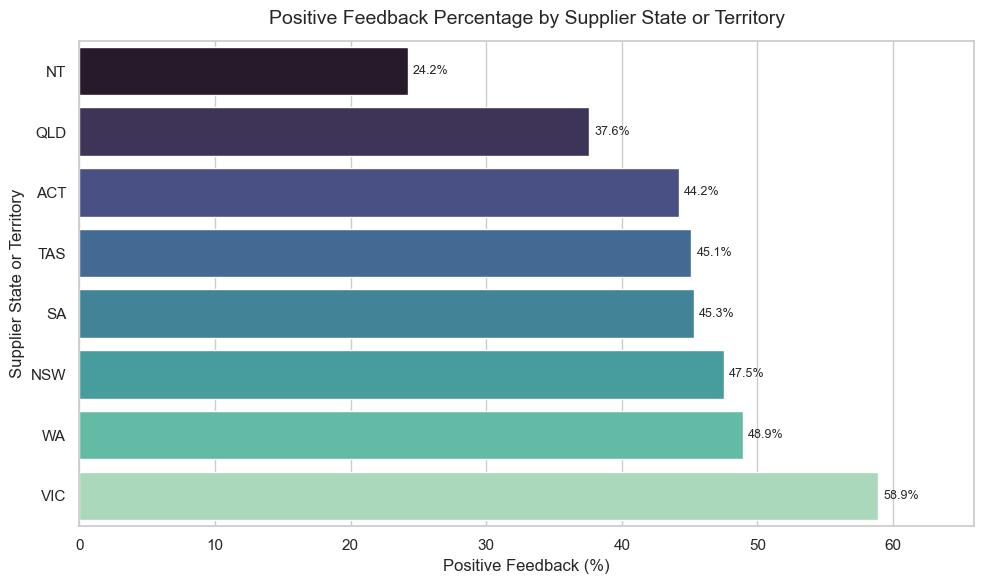

In [12]:
percentage_plot = feedback_by_state.sort_values("Positive_Percentage", ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=percentage_plot,
    x="Positive_Percentage",
    y="Supplier location",
    hue="Supplier location",
    palette="mako",
    legend=False
)

ax.set_title("Positive Feedback Percentage by Supplier State or Territory", fontsize=14, pad=12)
ax.set_xlabel("Positive Feedback (%)")
ax.set_ylabel("Supplier State or Territory")

for bar in ax.patches:
    width = bar.get_width()
    if pd.notna(width):
        ax.annotate(
            f"{width:.1f}%",
            (width, bar.get_y() + bar.get_height()/2),
            xytext=(4, 0),
            textcoords="offset points",
            va="center",
            fontsize=9
        )

ax.margins(x=0.12)
plt.tight_layout()
plt.show()

## 13. Discussion — Product Feedback

The product-feedback analysis defines positive feedback as responses recorded as “agree” or “strongly agree”. This definition is appropriate because both categories indicate a favourable evaluation, while neutral and negative categories are excluded. Across the full dataset, 440 of 900 responses were positive, representing 48.9% of all feedback. When the data is grouped by supplier state or territory, Victoria records the highest number of positive responses, with 185 positive responses from 314 total responses. This means 58.9% of Victorian responses were positive. New South Wales ranks second by count with 76 positive responses, while the Northern Territory records the lowest count with eight. Importantly, the number of positive responses should be interpreted together with the percentage because states have different numbers of observations. Victoria leads on both absolute count and positive-response rate among the larger states, suggesting stronger customer sentiment in that market. However, this descriptive result does not explain why feedback differs between locations. Differences may reflect product mix, service quality, store experience, customer expectations, or unequal sample sizes. From a business analytics perspective, AusiFood should investigate the drivers of Victoria’s stronger results and examine lower-performing states, particularly the Northern Territory and Queensland, to identify actionable service or product improvements.

# Question 2 — Does Sold Price Vary by City?
14. Select two suitable products

Products are compared according to the number of cities in which they occur. Cottage cheese and Wild Salmon are selected because both appear in all 15 cities, providing broad and consistent geographic coverage.

In [13]:
item_city_coverage = (
    s8200703_part2
    .groupby("Item", as_index=False)
    .agg(
        Number_of_Records=("sold price", "count"),
        Number_of_Cities=("City", "nunique")
    )
    .sort_values(["Number_of_Cities", "Number_of_Records"], ascending=[False, False])
    .reset_index(drop=True)
)

item_city_coverage.insert(0, "Serial Number", range(1, len(item_city_coverage)+1))

display(
    item_city_coverage.head(10).style
    .format({"Number_of_Records": "{:,.0f}", "Number_of_Cities": "{:,.0f}"})
    .hide(axis="index")
)

Serial Number,Item,Number_of_Records,Number_of_Cities
1,Cottage cheese,67,15
2,Cucumber,54,15
3,Beef,52,15
4,Lettuce,50,15
5,Mushrooms,42,15
6,Wild Salmon,39,15
7,Bananas,45,14
8,Milk,44,14
9,Eggs,41,14
10,Oranges,38,14


## 15. Product 1 — Cottage cheese

The data is filtered for Cottage cheese and grouped by city. Average sold price and transaction count are calculated.

In [15]:
cottage_cheese_price = (
    s8200703_part2
    .loc[s8200703_part2["Item"] == "Cottage cheese"]
    .groupby("City", as_index=False)
    .agg(
        Average_Sold_Price=("sold price", "mean"),
        Transactions=("sold price", "count")
    )
    .sort_values("Average_Sold_Price", ascending=False)
    .reset_index(drop=True)
)

cottage_cheese_price["Average_Sold_Price"] = cottage_cheese_price["Average_Sold_Price"].round(2)
cottage_cheese_price.insert(0, "Serial Number", range(1, len(cottage_cheese_price)+1))

display(
    cottage_cheese_price.style
    .format({"Average_Sold_Price": "${:,.2f}", "Transactions": "{:,.0f}"})
    .hide(axis="index")
)

Serial Number,City,Average_Sold_Price,Transactions
1,South Yarra - west,$9.26,4
2,Southbank,$9.02,6
3,Docklands,$8.97,4
4,East Melbourne,$8.95,5
5,Port Melbourne,$8.80,3
6,Parkville,$8.66,3
7,Carlton,$8.51,6
8,Princes Hill,$8.47,2
9,Fitzroy,$8.29,6
10,Richmond,$8.19,3


## 16. Visualise Cottage cheese prices

A multicoloured horizontal bar chart compares average sold price across all cities.

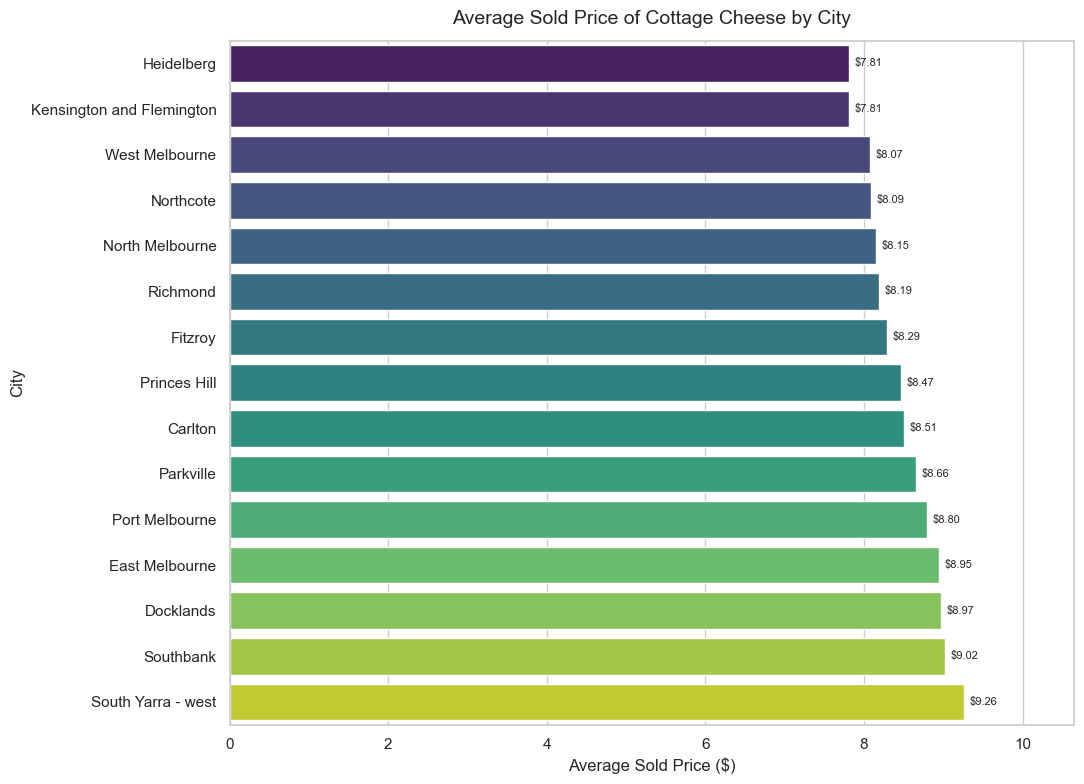

In [16]:
cottage_plot = cottage_cheese_price.sort_values("Average_Sold_Price", ascending=True)

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=cottage_plot,
    x="Average_Sold_Price",
    y="City",
    hue="City",
    palette="viridis",
    legend=False
)

ax.set_title("Average Sold Price of Cottage Cheese by City", fontsize=14, pad=12)
ax.set_xlabel("Average Sold Price ($)")
ax.set_ylabel("City")

for bar in ax.patches:
    width = bar.get_width()
    if pd.notna(width):
        ax.annotate(
            f"${width:,.2f}",
            (width, bar.get_y() + bar.get_height()/2),
            xytext=(4, 0),
            textcoords="offset points",
            va="center",
            fontsize=8
        )

ax.margins(x=0.15)
plt.tight_layout()
plt.show()

## 17. Product 2 — Wild Salmon

The same method is repeated for Wild Salmon to check whether the city-price pattern is also present for a second product.

In [17]:
wild_salmon_price = (
    s8200703_part2
    .loc[s8200703_part2["Item"] == "Wild Salmon"]
    .groupby("City", as_index=False)
    .agg(
        Average_Sold_Price=("sold price", "mean"),
        Transactions=("sold price", "count")
    )
    .sort_values("Average_Sold_Price", ascending=False)
    .reset_index(drop=True)
)

wild_salmon_price["Average_Sold_Price"] = wild_salmon_price["Average_Sold_Price"].round(2)
wild_salmon_price.insert(0, "Serial Number", range(1, len(wild_salmon_price)+1))

display(
    wild_salmon_price.style
    .format({"Average_Sold_Price": "${:,.2f}", "Transactions": "{:,.0f}"})
    .hide(axis="index")
)

Serial Number,City,Average_Sold_Price,Transactions
1,South Yarra - west,$24.45,3
2,East Melbourne,$24.07,2
3,Docklands,$23.70,8
4,Southbank,$23.42,2
5,Parkville,$23.36,1
6,Port Melbourne,$22.79,1
7,Carlton,$22.74,1
8,Richmond,$22.46,1
9,North Melbourne,$22.11,3
10,Fitzroy,$21.92,2


## 18. Visualise Wild Salmon prices

A second multicoloured bar chart applies the same visual structure for consistency.

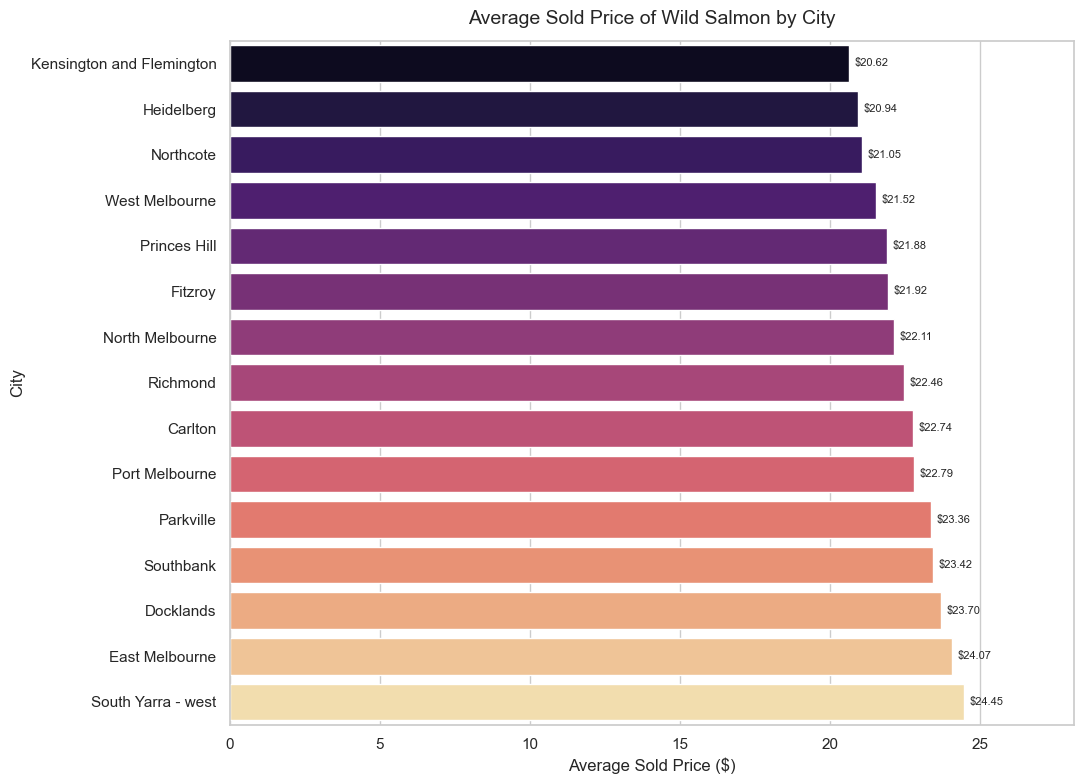

In [18]:
salmon_plot = wild_salmon_price.sort_values("Average_Sold_Price", ascending=True)

plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=salmon_plot,
    x="Average_Sold_Price",
    y="City",
    hue="City",
    palette="magma",
    legend=False
)

ax.set_title("Average Sold Price of Wild Salmon by City", fontsize=14, pad=12)
ax.set_xlabel("Average Sold Price ($)")
ax.set_ylabel("City")

for bar in ax.patches:
    width = bar.get_width()
    if pd.notna(width):
        ax.annotate(
            f"${width:,.2f}",
            (width, bar.get_y() + bar.get_height()/2),
            xytext=(4, 0),
            textcoords="offset points",
            va="center",
            fontsize=8
        )

ax.margins(x=0.15)
plt.tight_layout()
plt.show()

## 19. Summarise the price variation

This table compares the overall average price, lowest city average, highest city average, absolute price range, and percentage spread for the two products.

In [19]:
price_summary = pd.DataFrame({
    "Product": ["Cottage cheese", "Wild Salmon"],
    "Overall Average Price": [
        s8200703_part2.loc[s8200703_part2["Item"] == "Cottage cheese", "sold price"].mean(),
        s8200703_part2.loc[s8200703_part2["Item"] == "Wild Salmon", "sold price"].mean()
    ],
    "Lowest City Average": [
        cottage_cheese_price["Average_Sold_Price"].min(),
        wild_salmon_price["Average_Sold_Price"].min()
    ],
    "Highest City Average": [
        cottage_cheese_price["Average_Sold_Price"].max(),
        wild_salmon_price["Average_Sold_Price"].max()
    ]
})

price_summary["City Price Range"] = (
    price_summary["Highest City Average"] - price_summary["Lowest City Average"]
)

price_summary["Percentage Spread"] = (
    price_summary["City Price Range"] / price_summary["Lowest City Average"] * 100
)

price_summary.insert(0, "Serial Number", range(1, len(price_summary)+1))

display(
    price_summary.style
    .format({
        "Overall Average Price": "${:,.2f}",
        "Lowest City Average": "${:,.2f}",
        "Highest City Average": "${:,.2f}",
        "City Price Range": "${:,.2f}",
        "Percentage Spread": "{:.1f}%"
    })
    .hide(axis="index")
)

Serial Number,Product,Overall Average Price,Lowest City Average,Highest City Average,City Price Range,Percentage Spread
1,Cottage cheese,$8.45,$7.81,$9.26,$1.45,18.6%
2,Wild Salmon,$22.50,$20.62,$24.45,$3.83,18.6%


## 20. Discussion — Sold Price Variation Across Cities

The city-level price analysis compares two products that appear in all 15 cities: Cottage cheese and Wild Salmon. Using average sold price reduces the influence of transaction-level price fluctuations and provides a basis for comparison. Cottage cheese has an overall average sold price of approximately 8.45.Its city−level average ranges from about 7.81 in Kensington and Flemington to 9.26 in SouthYarra−west,a difference of approximately 1.46, or 18.7% relative to the lowest average. Wild Salmon shows a similar pattern. Its overall average sold price is approximately 22.50, while city averages range from 20.62 in Kensington and Flemington to 24.45 in South Yarra−west. This represents a difference of 3.83, or approximately 18.6%. Because both products show differences across cities, the results suggest that sold prices are not uniform across locations. The repeated pattern across two products strengthens this descriptive finding. However, the analysis demonstrates association rather than causation. Differences may reflect local pricing strategies, promotions, timing, supplier costs, store-level decisions, or customer demand. Transaction counts also vary by city, so averages based on fewer observations should be interpreted cautiously. Further analysis should test whether city-level price differences remain after controlling for year, discounts, and transaction volume.

## 21. Conclusion

The Part 2 analysis shows that Victoria has the highest positive-feedback count and that sold prices vary descriptively across cities for both selected products. The results demonstrate how data cleaning, transformation, aggregation, visualisation, and interpretation can support business decision-making.